# Convolutional Neural Network

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
import lightning as L
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

## Creating Images 

In [2]:
# We create an image of the letter O using a 6X6 matrix.
o_image = ([0, 0, 1, 1, 0, 0],
           [0, 1, 0, 0, 1, 0],
           [1, 0, 0, 0, 0, 1],
           [1, 0, 0, 0, 0, 1],
           [0, 1, 0, 0, 1, 0],
           [0, 0, 1, 1, 0, 0])

# We create an image of the letter X using a 6X6 matrix.
x_image = ([1, 0, 0, 0, 0, 1],
           [0, 1, 0, 0, 1, 0],
           [0, 0, 1, 1, 0, 0],
           [0, 0, 1, 1, 0, 0],
           [0, 1, 0, 0, 1, 0],
           [1, 0, 0, 0, 0, 1])


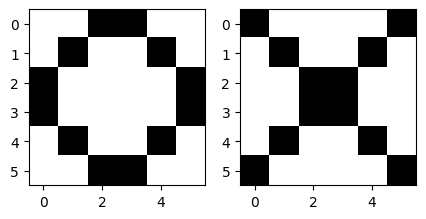

In [3]:
# we use matplotlib to visualize them.
fig, axarr = plt.subplots(nrows=1, ncols=2, figsize=(5, 5))

axarr[0].imshow(o_image, cmap='gray_r')
axarr[1].imshow(x_image, cmap='gray_r')

## Building DataLoader 

In [4]:
# We convert images into tensors. 
input_images = torch.tensor([o_image, x_image]).type(torch.float32)

# We create tensors for the ideal output values. Our CNN has 2 outputs (O and X), so [1.0, 0.0] will represent letter O and [0.0, 1.0] the letter X.
input_labels = torch.tensor([[1.0, 0.0], [0.0, 1.0]]).type(torch.float32)


# We combine 'input_images' and input_labels' to create a TensorDataset and use that to create a DataLoader.
dataset = TensorDataset(input_images, input_labels)
dataloader = DataLoader(dataset)

In [5]:
# We can see what is inside the DataLoader.
for batch_num, (images, labels) in enumerate(dataloader):
    print('batch_num: ', batch_num)
    print(images)
    print(labels)
    print()

batch_num:  0
tensor([[[0., 0., 1., 1., 0., 0.],
         [0., 1., 0., 0., 1., 0.],
         [1., 0., 0., 0., 0., 1.],
         [1., 0., 0., 0., 0., 1.],
         [0., 1., 0., 0., 1., 0.],
         [0., 0., 1., 1., 0., 0.]]])
tensor([[1., 0.]])

batch_num:  1
tensor([[[1., 0., 0., 0., 0., 1.],
         [0., 1., 0., 0., 1., 0.],
         [0., 0., 1., 1., 0., 0.],
         [0., 0., 1., 1., 0., 0.],
         [0., 1., 0., 0., 1., 0.],
         [1., 0., 0., 0., 0., 1.]]])
tensor([[0., 1.]])



## Building a CNN

In [6]:
class SimpleCNN(L.LightningModule):
    def __init__(self):
        super().__init__()

        L.seed_everything(seed=42)

        self.conv = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=3) # black & white image has only 1 channel, we want 3X3 filter so kernel_size=3
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2) # we want 2X2 filter for the pooling  so kernel_size=2, we want to move 2 units at a time so stride=2.

        self.input_to_hidden = nn.Linear(in_features=4, out_features=1)
        self.hidden_to_output = nn.Linear(in_features=1, out_features=2)
        
        self.loss = nn.CrossEntropyLoss()

    def forward(self, x):
        # we apply a filter to the input image, run it through a ReLu and lastly through a Max Pooling layer.
        x = self.conv(x)
        x=F.relu(x)
        x=self.pool(x)
        # at this point we have a matrix of values. We use 'torch.flatten() to turn the matrix into a vector to use in the Neural Network.
        x = torch.flatten(x, 1) # flatten all dimensions except batch

        # lastly we run the flattened values through a neural network
        x = self.input_to_hidden(x)
        x = F.relu(x)
        x = self.hidden_to_output(x)
        return x
    
    def configure_optimizers(self):
        return Adam(self.parameters(), lr=0.01)
    
    def training_step(self, batch, batch_idx):
        inputs, labels = batch
        outputs = self.forward(inputs)
        loss = self.loss(outputs, labels)
        return loss


## Training the Neural Network

In [7]:
model = SimpleCNN()

trainer = L.Trainer(max_epochs=700)
trainer.fit(model, train_dataloaders=dataloader)

Seed set to 42
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
/Users/odysseasgeorgiades/Desktop/Neural Networks/.venv/lib/python3.14/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmo

Epoch 699: 100%|██████████| 2/2 [00:00<00:00, 278.36it/s, v_num=3]

`Trainer.fit` stopped: `max_epochs=700` reached.


Epoch 699: 100%|██████████| 2/2 [00:00<00:00, 151.69it/s, v_num=3]


In [8]:
for batch_num, (image, label) in enumerate(dataloader):
    prediction = model(image)
    predicted_label = torch.round(torch.softmax(prediction, dim=1), decimals=2)

    print("predicted_label: ", predicted_label)
    print("original label: ", label)
    print("\n")

predicted_label:  tensor([[0.9900, 0.0100]], grad_fn=<RoundBackward1>)
original label:  tensor([[1., 0.]])


predicted_label:  tensor([[0., 1.]], grad_fn=<RoundBackward1>)
original label:  tensor([[0., 1.]])




## Make predictions with new data

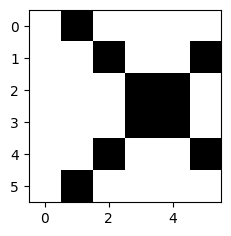

In [9]:
# We will shift letter X by one pixel. 
shifted_x_image = ([0, 1, 0, 0, 0, 0],
                   [0, 0, 1, 0, 0, 1],
                   [0, 0, 0, 1, 1, 0],
                   [0, 0, 0, 1, 1, 0],
                   [0, 0, 1, 0, 0, 1],
                   [0, 1, 0, 0, 0, 0])

fig, ax = plt.subplots(figsize=(2.5, 2.5))
ax.imshow(shifted_x_image, cmap="gray_r")

In [10]:
# we add to the model the image converted to tensor. 
prediction = model(torch.tensor([shifted_x_image]).type(torch.float32))

# we make the prediciton easy to read by running it through torch.softmax() and torch.round()
predicted_label = torch.round(torch.softmax(prediction, dim=1), decimals=2)
predicted_label

tensor([[0.0200, 0.9800]], grad_fn=<RoundBackward1>)

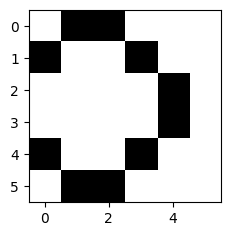

In [11]:
# now we do the same for O. 
shifted_o_image = ([0, 1, 1, 0, 0, 0],
                   [1, 0, 0, 1, 0, 0],
                   [0, 0, 0, 0, 1, 0],
                   [0, 0, 0, 0, 1, 0],
                   [1, 0, 0, 1, 0, 0],
                   [0, 1, 1, 0, 0, 0])

fig, ax = plt.subplots(figsize=(2.5, 2.5))
ax.imshow(shifted_o_image, cmap="gray_r")

In [12]:
prediction = model(torch.tensor([shifted_o_image]).type(torch.float32))
predicted_label = torch.round(torch.softmax(prediction, dim=1), decimals=2)
predicted_label

tensor([[0.8000, 0.2000]], grad_fn=<RoundBackward1>)